# All model bands together: K₀ = 200–350 MeV

Six models (Dieterici/Clausius × vdW/CS/TVM) appear together in every panel, with **model marker shapes**, **K₀ colors**, and **black lines for the two vdW-repulsion models**. The rows/panels distinguish $b_{pn}\ne b_n$ from $b_{pn}=b_n$.

The master figure combines sound speed, full mass–radius sequences, EoS and quark fraction. Individual two-panel figures are also exported. Density plots reach $n_B/n_0=15$ and mass–radius sequences include the descending branch with no fixed axis crop.

Bands use the available computed K₀ = **200, 250, 300, 350 MeV** samples. The single central line defaults to **275 MeV**, linearly interpolated between the 250 and 300 curves as a **display guide, not a new EoS/TOV calculation**. Set `CENTER_K0 = 300` for a directly computed reference line. Envelopes are sampled model ranges, not statistical confidence intervals.

Dieterici–TVM, K₀=350, unequal-b had a saved energy-minimization jump at n/n₀ = 14–15. The helper recomputes the four affected densities with a global quark-fraction scan and refines its minima, retaining the original physical settings. Corrected copies and diagnostics are saved separately; the original data stay available. The missing TOV sequence is reintegrated with failed stars recorded rather than aborting all central densities.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/qmm').is_dir())
sys.path.insert(0, str(ROOT / 'scripts'))
import plot_combined_model_bands as combined
from IPython.display import Image, display

CENTER_K0 = 275.0  # Interpolated guide; set 300.0 for a computed middle line.
RECOVER_MISSING = True  # Reuse corrected products, or recompute if absent.
figure_paths, coverage = combined.main(center_k0=CENTER_K0, recover=RECOVER_MISSING)
display(coverage)


,model,branch,K0_MeV,eos_points,max_n_over_n0,valid_stars,eos_source,mr_source
0,dieterici_vdw,target_l,200,150,15.0,219,results/generated/guided_dieterici_vdw_lambda3...,results/generated/guided_dieterici_vdw_lambda3...
1,dieterici_vdw,target_l,250,150,15.0,222,results/generated/guided_dieterici_vdw_lambda3...,results/generated/guided_dieterici_vdw_lambda3...
2,dieterici_vdw,target_l,300,150,15.0,227,results/generated/guided_dieterici_vdw_lambda3...,results/generated/guided_dieterici_vdw_lambda3...
3,dieterici_vdw,target_l,350,150,15.0,231,results/generated/guided_dieterici_vdw_lambda3...,results/generated/guided_dieterici_vdw_lambda3...
4,dieterici_vdw,equal_b,200,150,15.0,230,results/generated/guided_dieterici_vdw_lambda3...,results/generated/guided_dieterici_vdw_lambda3...
5,dieterici_vdw,equal_b,250,150,15.0,235,results/generated/guided_dieterici_vdw_lambda3...,results/generated/guided_dieterici_vdw_lambda3...
6,dieterici_vdw,equal_b,300,150,15.0,239,results/generated/guided_dieterici_vdw_lambda3...,results/generated/guided_dieterici_vdw_lambda3...
7,dieterici_vdw,equal_b,350,150,15.0,243,results/generated/guided_dieterici_vdw_lambda3...,results/generated/guided_dieterici_vdw_lambda3...
8,dieterici_cs,target_l,200,150,15.0,221,results/generated/guided_dieterici_cs_lambda30...,results/generated/guided_dieterici_cs_lambda30...
9,dieterici_cs,target_l,250,150,15.0,226,results/generated/guided_dieterici_cs_lambda30...,results/generated/guided_dieterici_cs_lambda30...


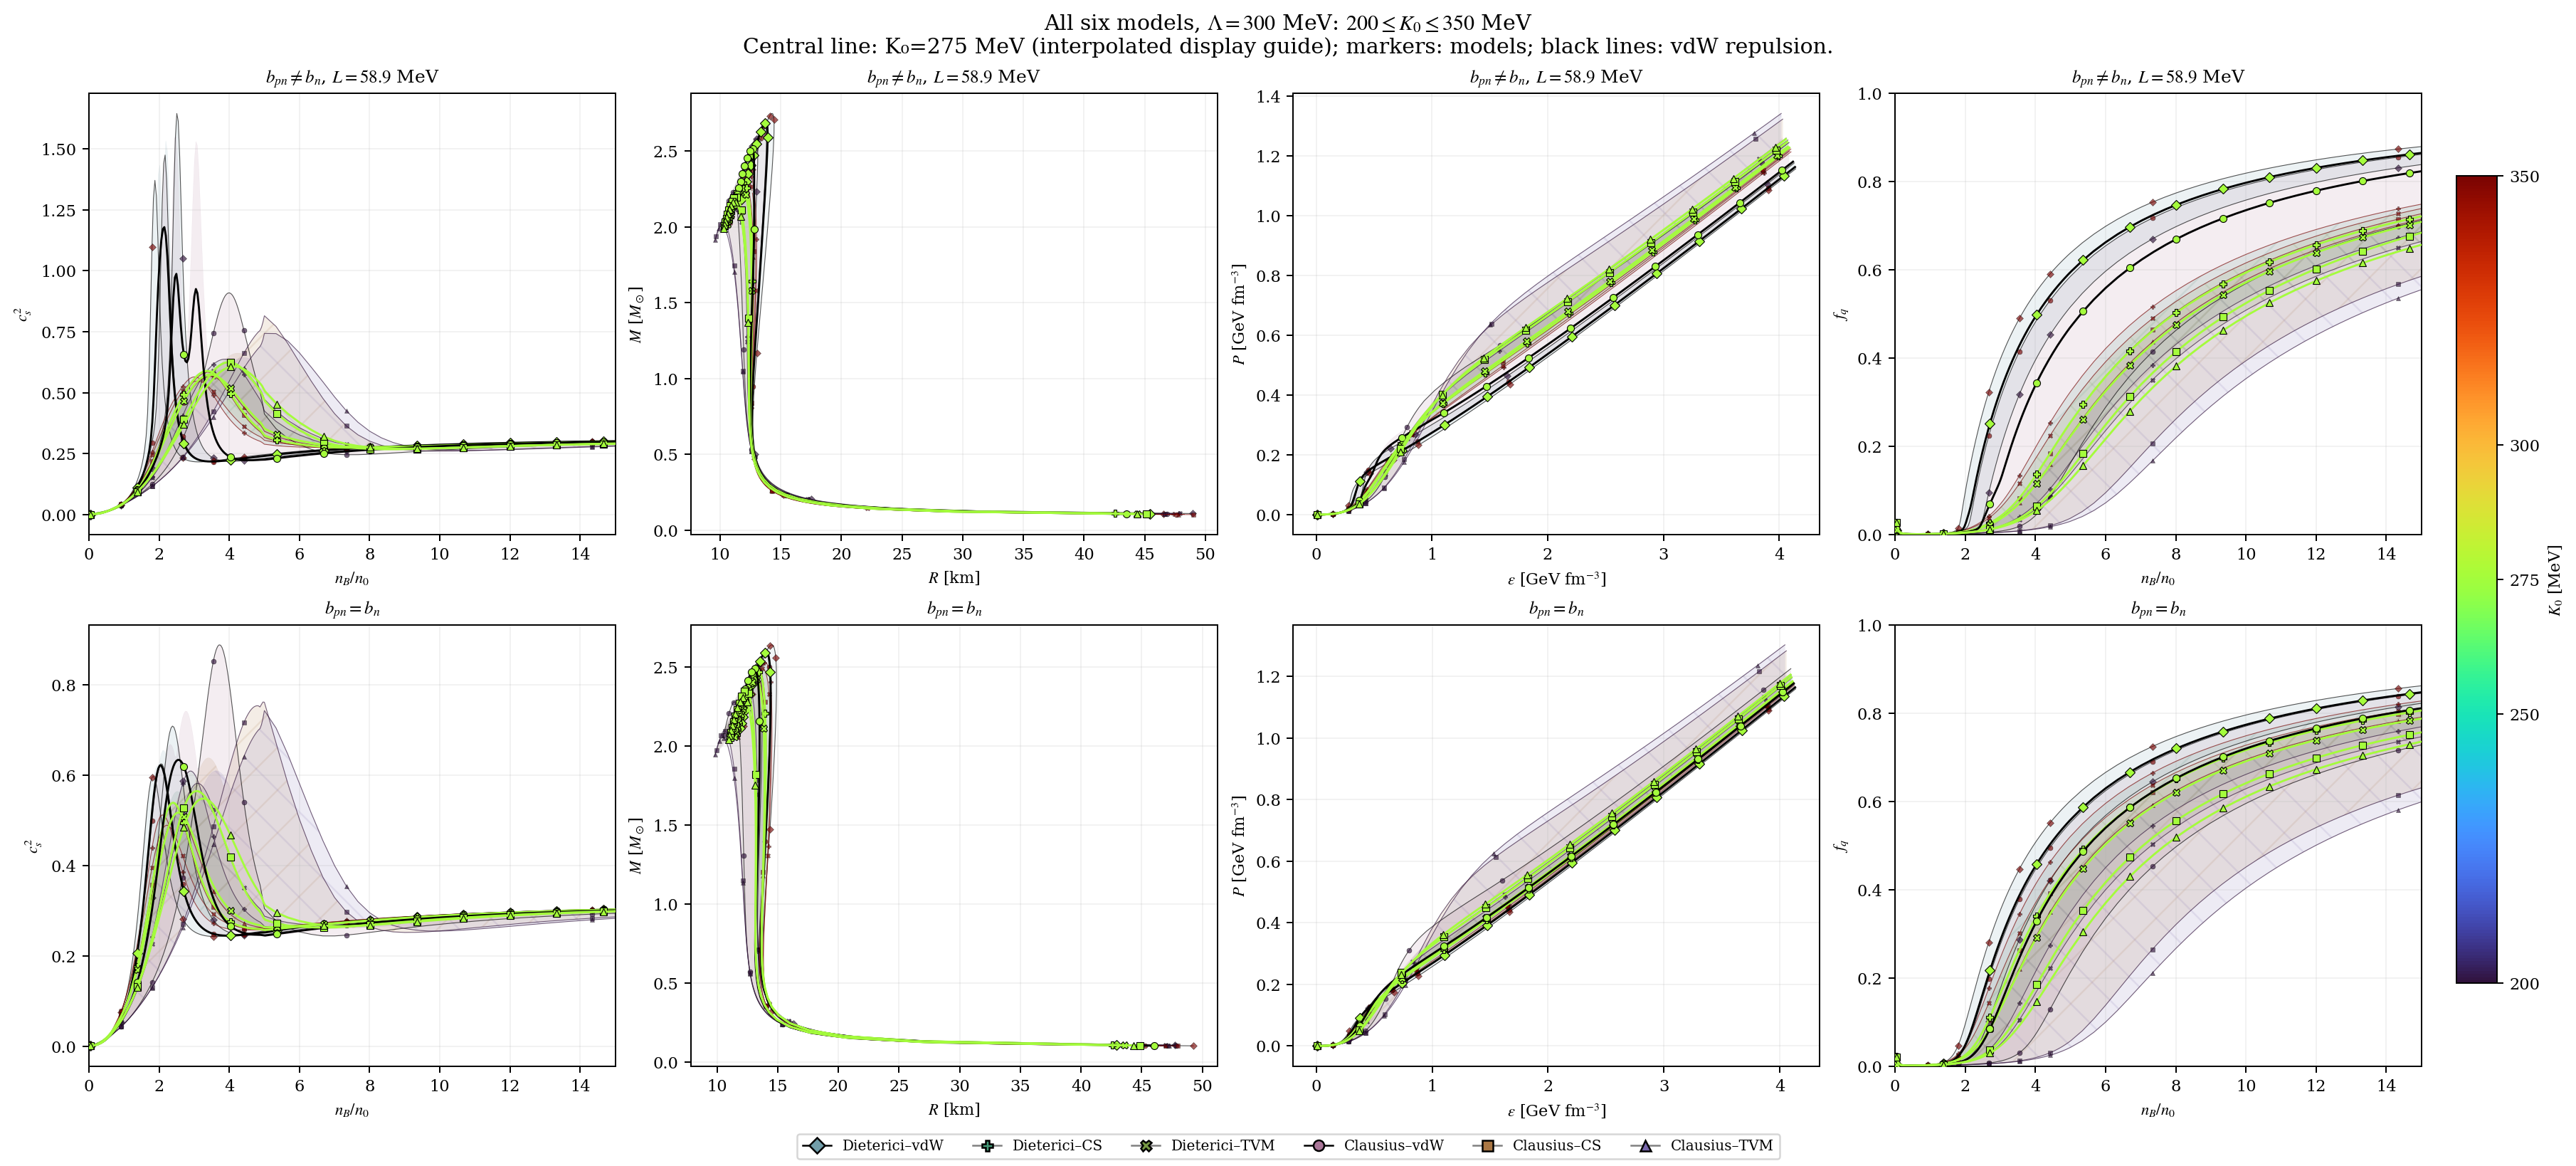

In [2]:
display(Image(filename=str(figure_paths[0])))


PNG/PDF/SVG figures: /home/dajuarez4/QMM/Paper/combined_models_K0_200_350


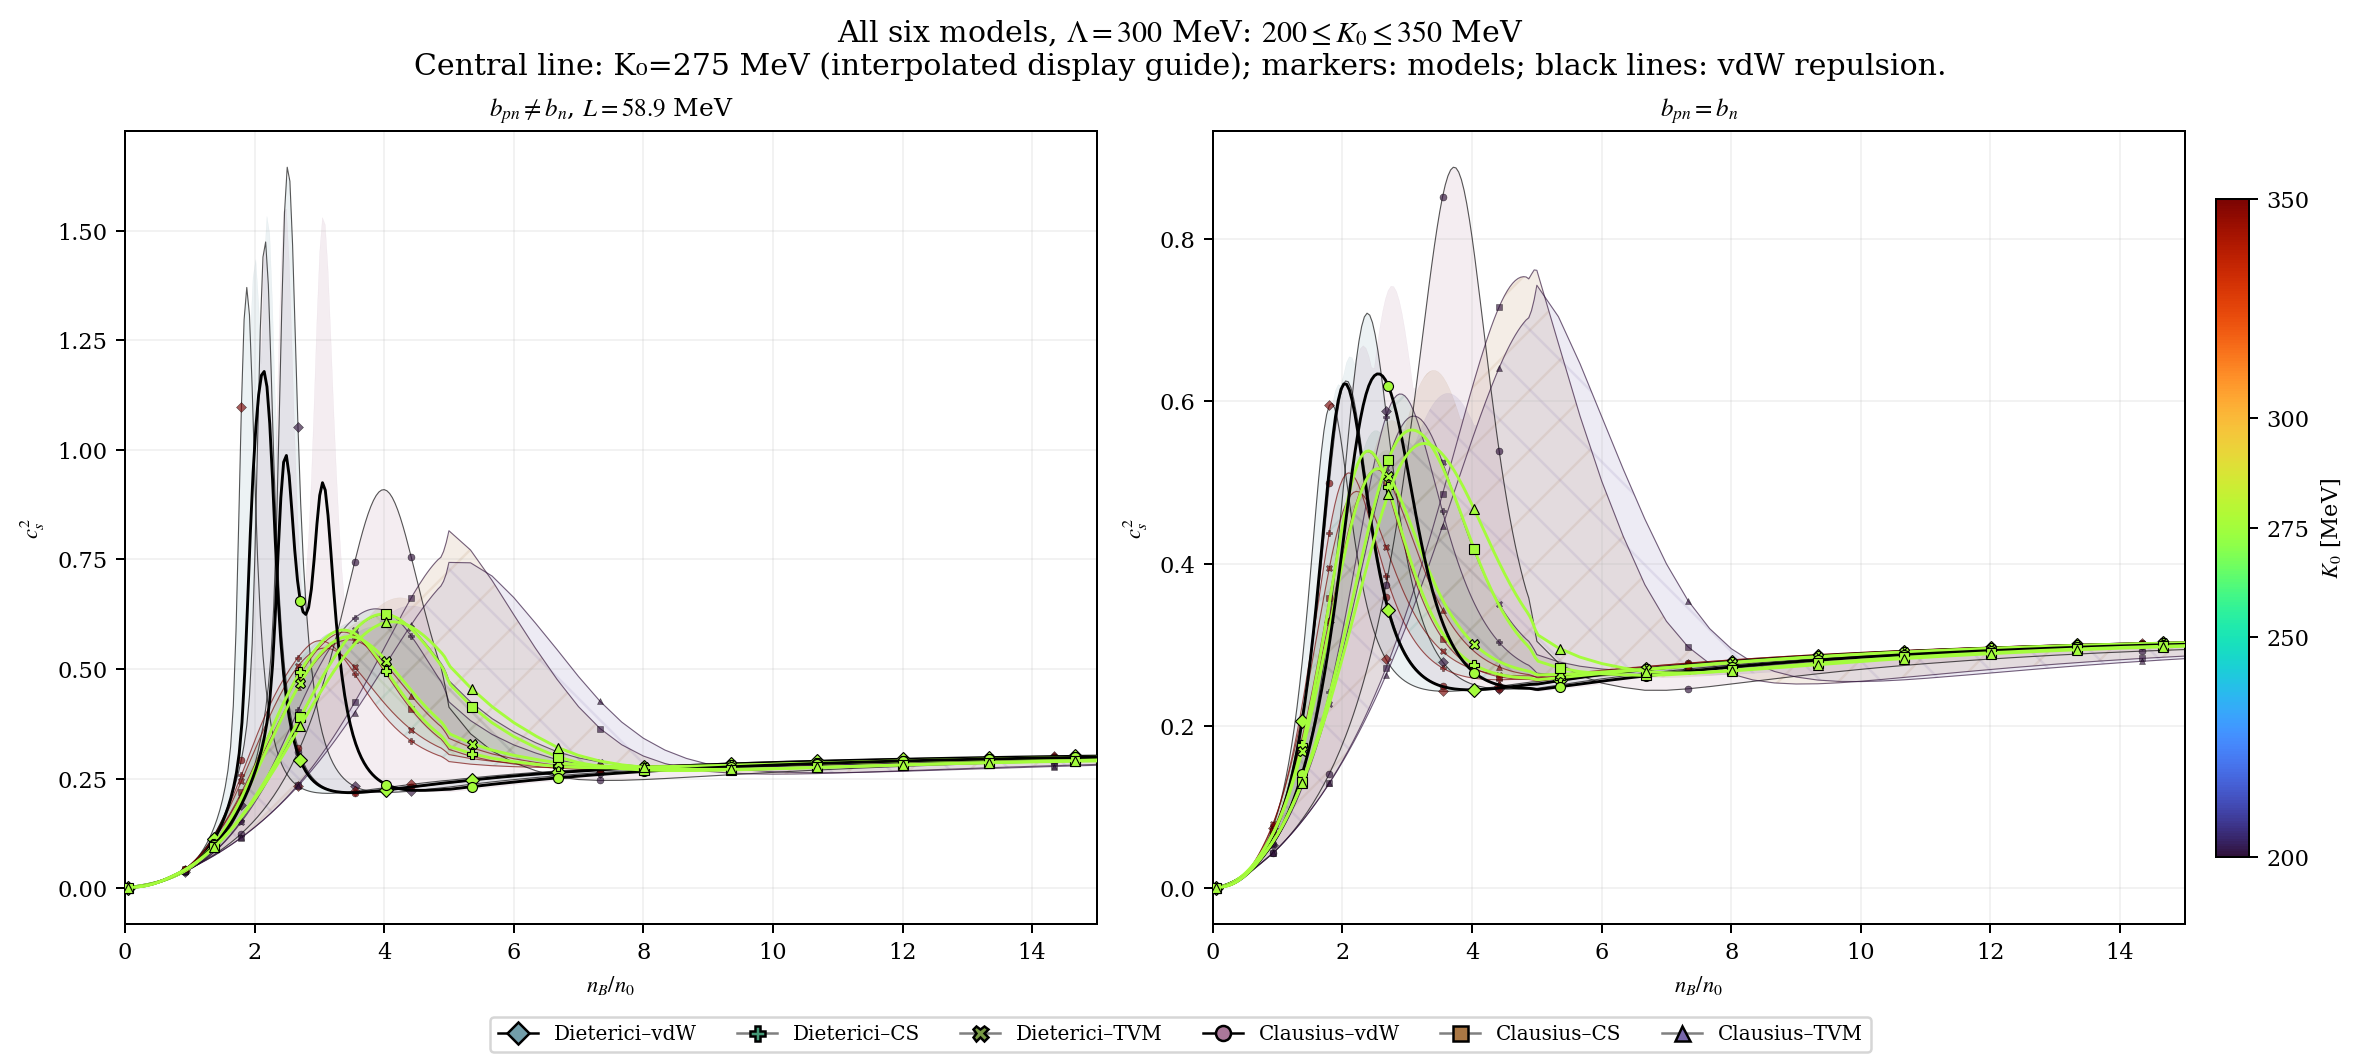

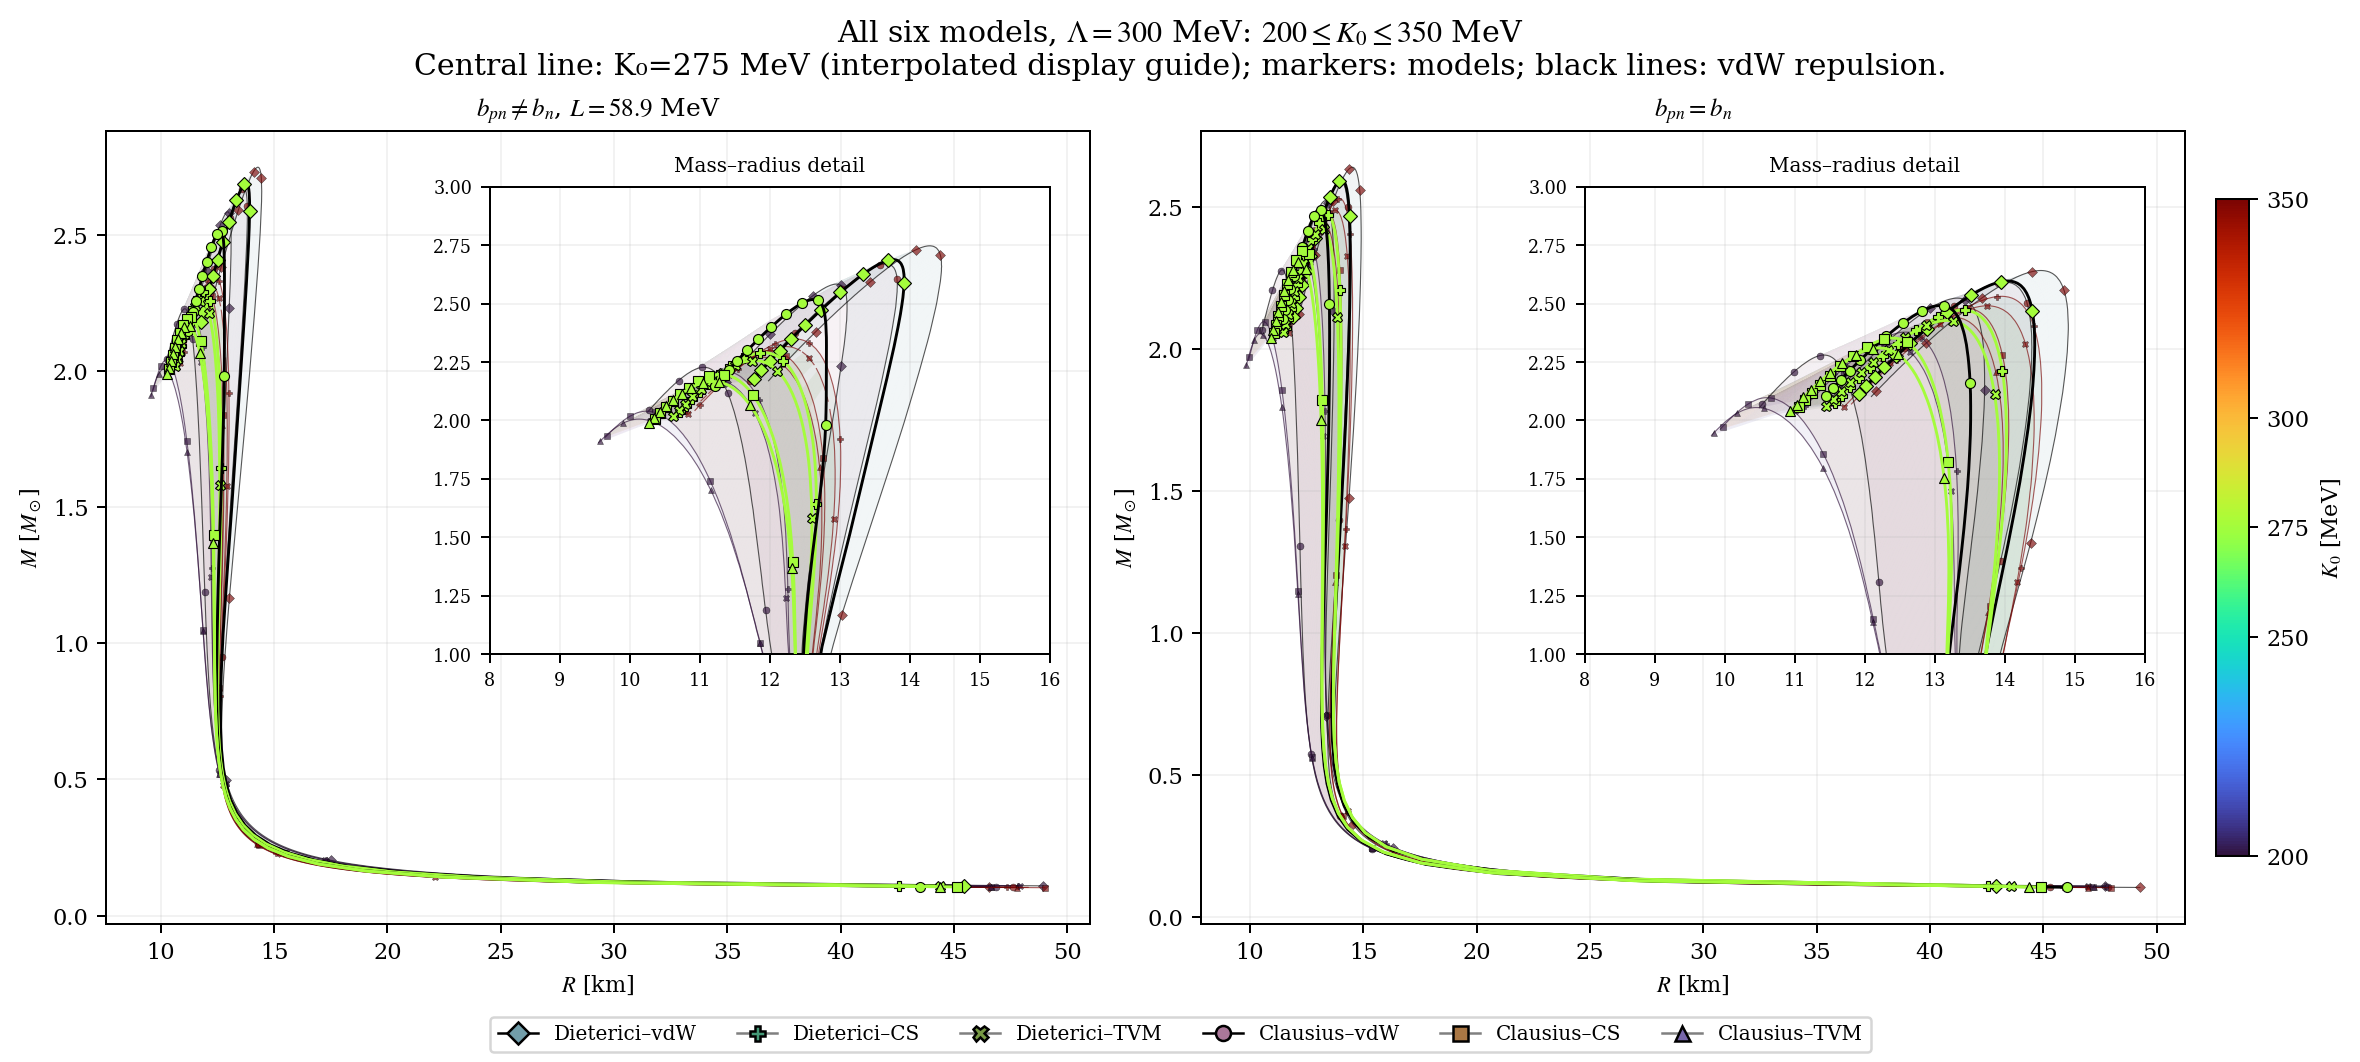

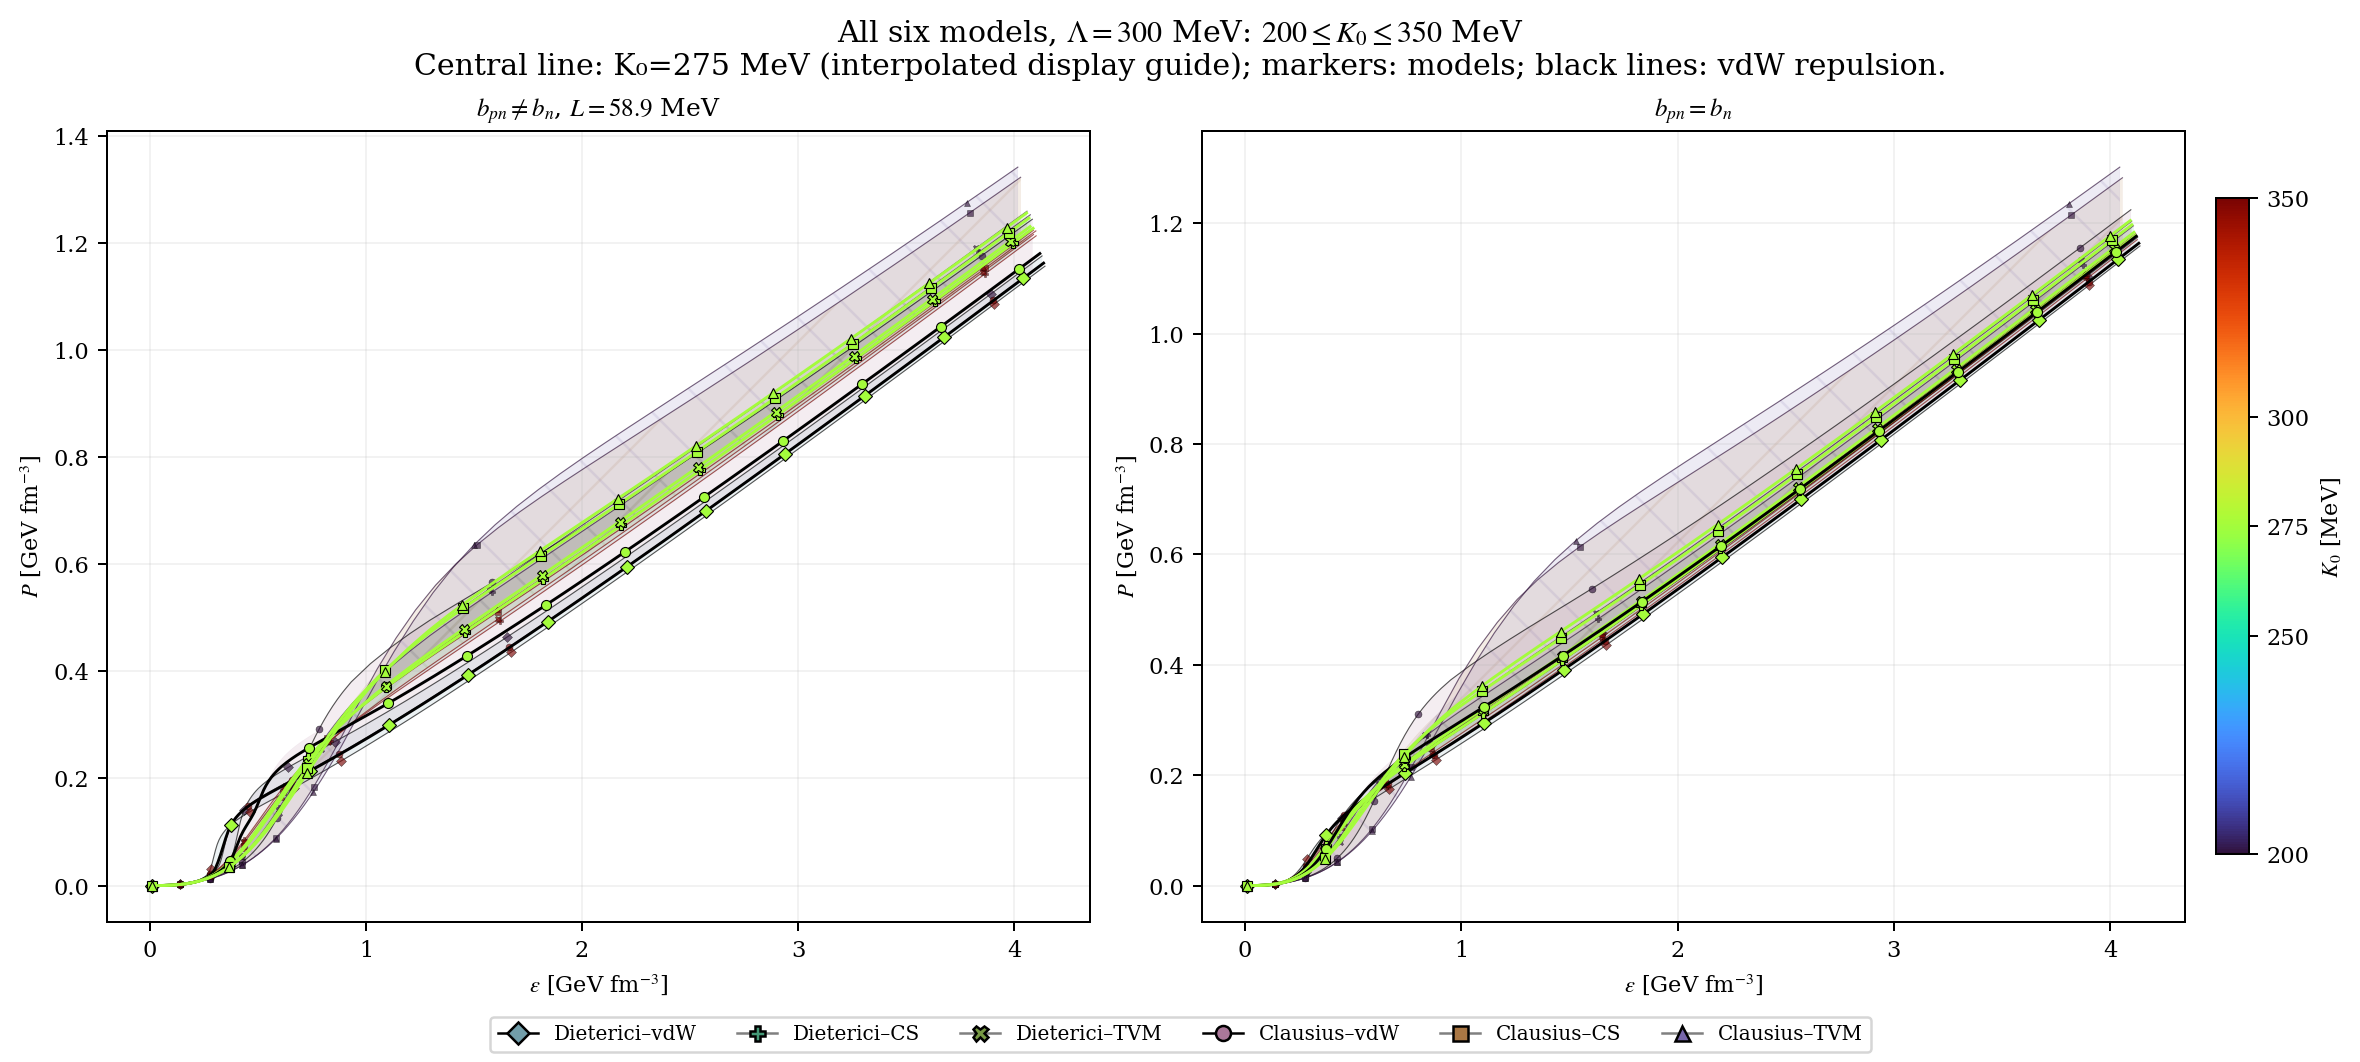

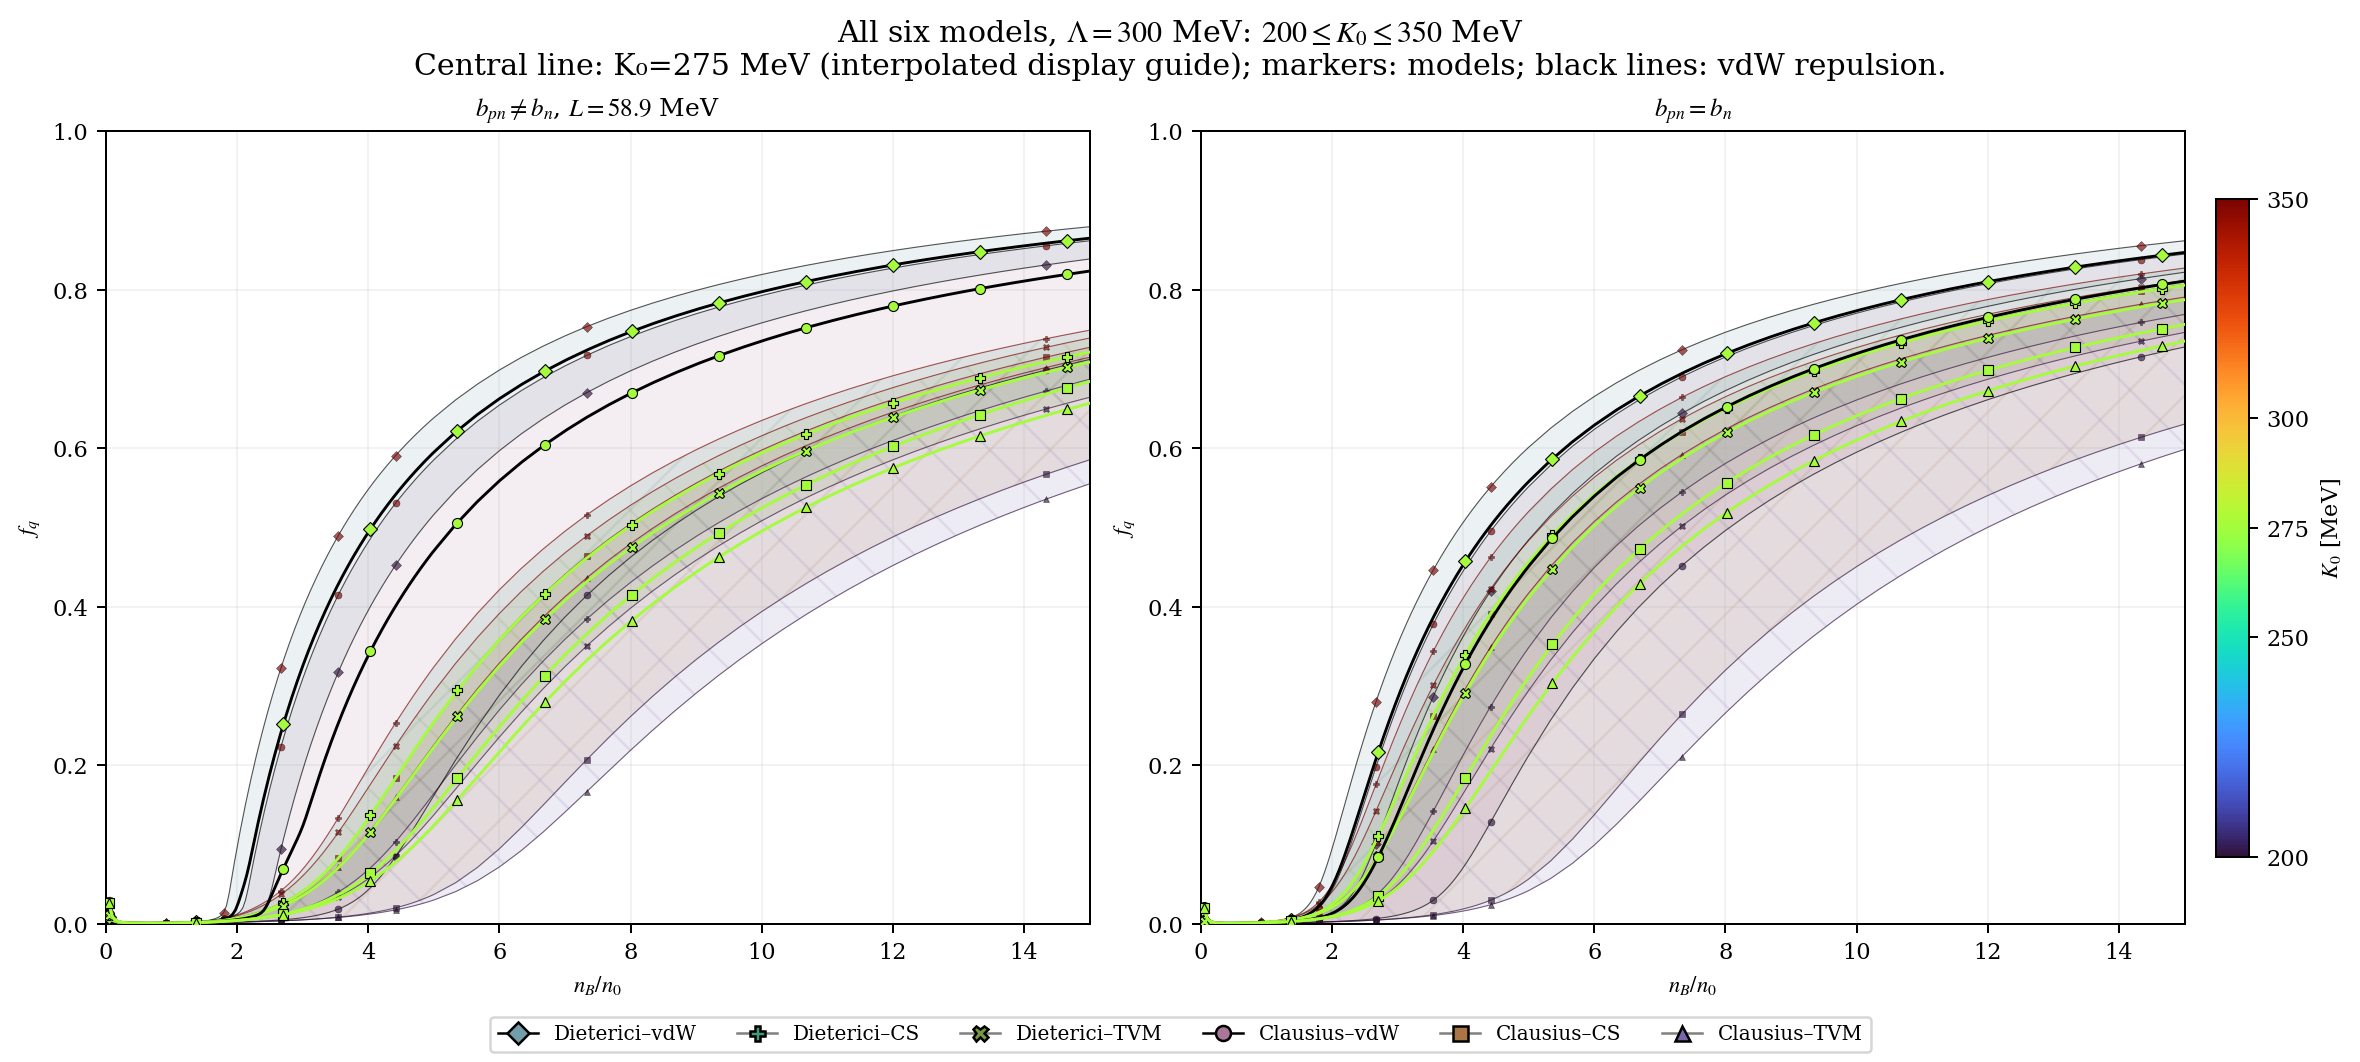

In [3]:
for path in figure_paths[1:]:
    display(Image(filename=str(path)))
print('PNG/PDF/SVG figures:', combined.OUTPUT)


In [4]:
assert len(coverage) == 48
assert coverage.eos_points.gt(0).all()
assert coverage.valid_stars.gt(0).all()
assert coverage.max_n_over_n0.between(14.999, 15.001).all()
print('All 48 model/K₀/branch combinations have EoS and mass–radius samples.')
print('All EoS extend to 15 n₀. Rejected-star diagnostics:')
import pandas as pd
for path in (combined.OUTPUT / 'recovered').glob('*mass_radius.csv'):
    frame = pd.read_csv(path)
    print(path.name, frame.status.value_counts().to_dict())


All 48 model/K₀/branch combinations have EoS and mass–radius samples.
All EoS extend to 15 n₀. Rejected-star diagnostics:
dieterici_tvm_K0_350_target_l_mass_radius.csv {'ok': 215, 'failed': 45}
